# LaCAM → LNS quality over time

Two neighborhood-4 instances with non-trivial LaCAM runtimes: one improves substantially under LNS and one does not improve at all. Quality is `−SoD/LB`, so higher is better. Before LaCAM finds a solution, each plot uses a finite sentinel below the initial quality; conceptually, this region is `−∞`.

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "datasets" / "movingai_final.csv").is_file():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("Run this notebook from inside the repository")
    ROOT = ROOT.parent

INSTANCE_IDS = [
    "maze-32-32-4-random-12-density-b6-n260",  # clear LNS improvement
    "maze-128-128-1-random-1-density-b2-n596",  # no LNS improvement
]
data = pd.read_csv(ROOT / "datasets" / "movingai_final.csv")
selected = data[
    data["instance_id"].isin(INSTANCE_IDS)
    & data["lns_neighborhood_size"].eq(4)
    & data["lacam_seed"].eq(0)
].set_index("instance_id").loc[INSTANCE_IDS].reset_index()
assert len(selected) == len(INSTANCE_IDS)

In [5]:
summary = selected[[
    "instance_id", "num_agents", "lns_neighborhood_size",
    "lacam_runtime_seconds", "lacam_initial_sod", "final_lns_sod", "lower_bound_soc",
]].copy()
summary["lacam_sodlb"] = summary["lacam_initial_sod"] / summary["lower_bound_soc"]
summary["lns_final_sodlb"] = summary["final_lns_sod"] / summary["lower_bound_soc"]
summary["sodlb_improvement"] = summary["lacam_sodlb"] - summary["lns_final_sodlb"]
summary

,instance_id,num_agents,lns_neighborhood_size,lacam_runtime_seconds,lacam_initial_sod,final_lns_sod,lower_bound_soc,lacam_sodlb,lns_final_sodlb,sodlb_improvement
0,maze-32-32-4-random-12-density-b6-n260,260,4,0.253,34927.0,27133.5,11286,3.094719,2.404173,0.690546
1,maze-128-128-1-random-1-density-b2-n596,596,4,0.907,738996.0,738991.0,229002,3.227029,3.227007,0.000022


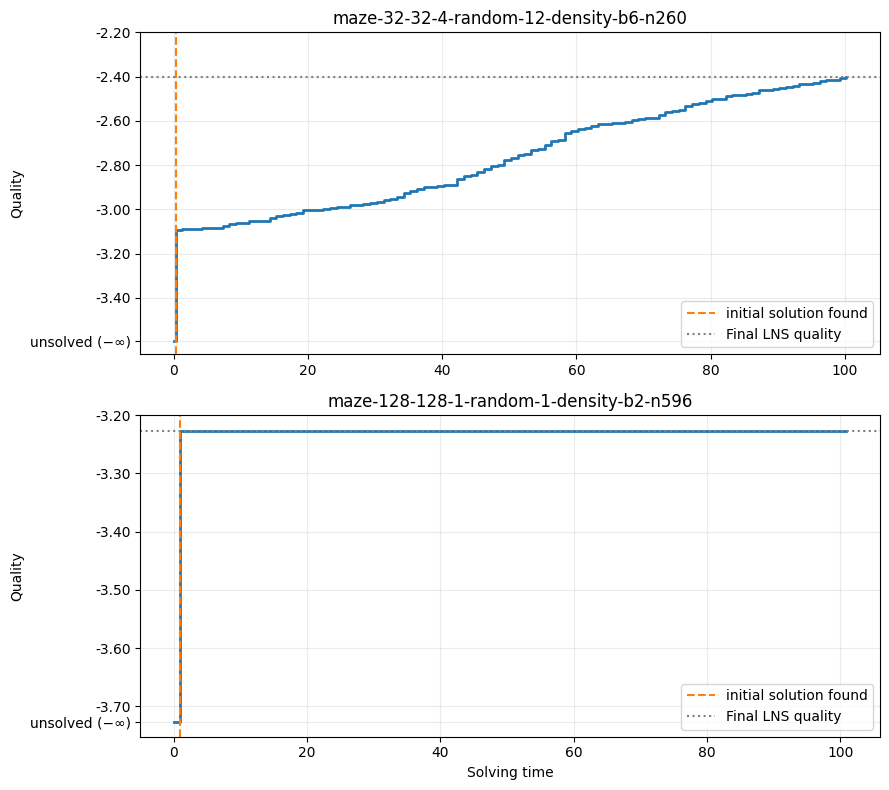

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8))

for ax, (_, instance) in zip(axes, selected.iterrows()):
    lns_sod = np.asarray(json.loads(instance["lns_best_sod_by_second"]), dtype=float)
    lacam_seconds = float(instance["lacam_runtime_seconds"])
    lns_quality = -lns_sod / float(instance["lower_bound_soc"])
    unsolved_quality = float(lns_quality[0] - 0.5)  # plotting stand-in for -infinity
    time = np.r_[0.0, np.nextafter(lacam_seconds, 0.0), lacam_seconds + np.arange(len(lns_sod))]
    quality = np.r_[unsolved_quality, unsolved_quality, lns_quality]

    ax.step(time, quality, where="post", linewidth=2)
    ax.axvline(lacam_seconds, color="tab:orange", linestyle="--", label="initial solution found")
    ax.axhline(lns_quality[-1], color="0.5", linestyle=":", label="Final LNS quality")
    ax.set(title=instance["instance_id"], ylabel="Quality")
    ticks = ax.get_yticks()
    visible_ticks = ticks[ticks > unsolved_quality]
    ax.set_yticks(
        [unsolved_quality, *visible_ticks],
        ["unsolved (−∞)", *[f"{value:.2f}" for value in visible_ticks]],
    )
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Solving time")
plt.tight_layout()
plt.show()